# Análisis original reorganizado
Código del proyecto académico. Las salidas conservadas son históricas: no se volvió a ejecutar sin `landing_experiment.csv`. Se retiraron consignas y comentarios de revisión de esta copia de portafolio; el archivo adjunto original no se modifica.

Coloca el CSV en `data/landing_experiment.csv`. Revisa la interpretación actualizada en el notebook principal: el gasto original se limita a compradores, el t-test supone varianzas iguales y las pruebas por segmento son marginales. Un p impreso como 0.0000 está redondeado.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / 'data').is_dir(): ROOT = ROOT.parent
df = pd.read_csv(ROOT / 'data/landing_experiment.csv')


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


In [5]:
print("Total de registros:", df.shape[0])
print("Usuarios únicos:",df["user_id"].nunique())


Total de registros: 40000
Usuarios únicos: 40000


In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


In [8]:
# Resumen estadístico
print(df["gasto"].describe())

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64


In [9]:
# Resumen estadístico de usuarios que se convirtieron
print(df[df["converted"] == 1]["gasto"].describe())

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64


In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ["landing", "region", "dispositivo", "traffic_source", "user_type"]:
    print(f"\n{col}:\n{df[col].value_counts()}")


Conteo de categorías:

landing:
B    20018
A    19982
Name: landing, dtype: int64

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


In [11]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"]
gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [12]:
from scipy import stats
# Aplicar prueba
stat, p_value = stats.ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico : -9.3656
Valor p: 0.0000


In [13]:
from scipy.stats import chi2_contingency
# Número de usuarios convertidos por página
convertidos = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
total = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", total)

# Aplicar prueba
tabla = pd.crosstab(df["landing"], df["converted"])
stat, p_value, dof, expected = chi2_contingency(tabla)

# Visualizar resultados
print(f"Estadístico: {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64
Estadístico: 93.3748
Valor p: 0.0000


In [14]:
# Aplicar prueba
tabla4 = pd.crosstab(df["traffic_source"], df["converted"])
stat4, p_value4, dof4, expected4 = chi2_contingency(tabla4)

print(f"Estadístico: {stat4:.4f}")
print(f"Valor p: {p_value4:.4f}")


Estadístico: 8.6621
Valor p: 0.0341


In [15]:
# Aplicar prueba
tabla5 = pd.crosstab(df["user_type"], df["converted"])
stat5, p_value5, dof5, expected5 = chi2_contingency(tabla5)

print(f"Estadístico: {stat5:.4f}")
print(f"Valor p: {p_value5:.4f}")


Estadístico: 0.5135
Valor p: 0.4736


In [16]:
# Fuente de tráfico vs conversión
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])
tabla_trafico.columns = ["No convirtió", "Convirtió"]

print(tabla_trafico)
print("\nProporción:")
print(tabla_trafico.div(tabla_trafico.sum(axis=1), axis=0).round(4) * 100)


                No convirtió  Convirtió
traffic_source                         
Ads                    10176       1759
Email                   5205        918
Organic                15507       2480
Referral                3406        549

Proporción:
                No convirtió  Convirtió
traffic_source                         
Ads                    85.26      14.74
Email                  85.01      14.99
Organic                86.21      13.79
Referral               86.12      13.88


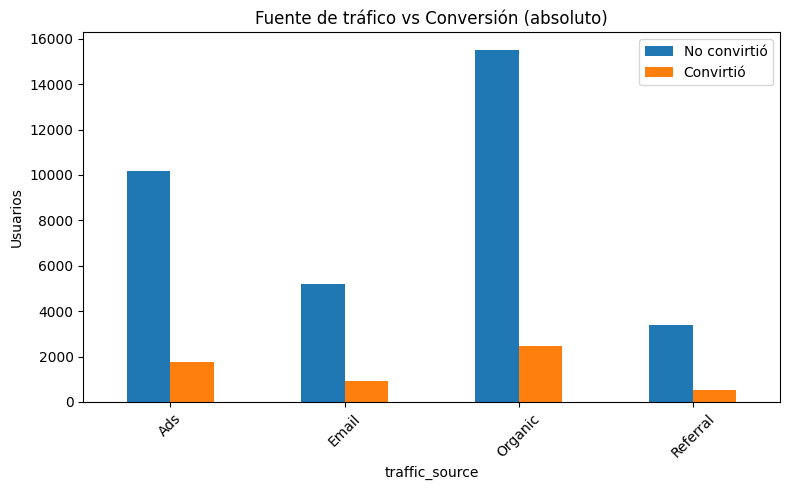

In [17]:
# Gráfico absoluto
tabla_trafico.plot(kind="bar", figsize=(8,5), title="Fuente de tráfico vs Conversión (absoluto)")
plt.ylabel("Usuarios")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

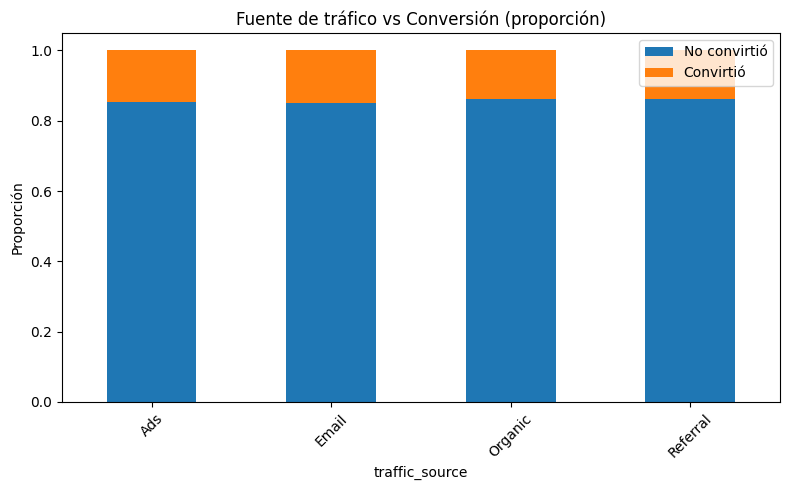

In [18]:
# Gráfico proporcional
tabla_trafico_pct = tabla_trafico.div(tabla_trafico.sum(axis=1), axis=0)
tabla_trafico_pct.plot(kind="bar", stacked=True, figsize=(8,5), title="Fuente de tráfico vs Conversión (proporción)")
plt.ylabel("Proporción")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# 6.2 Tipo de usuario vs conversión
tabla_usuario = pd.crosstab(df["user_type"], df["converted"])
tabla_usuario.columns = ["No convirtió", "Convirtió"]
print(tabla_usuario)
print("\nProporción:")
print(tabla_usuario.div(tabla_usuario.sum(axis=1), axis=0).round(4) * 100)


            No convirtió  Convirtió
user_type                          
Nuevo              22295       3738
Recurrente         11999       1968

Proporción:
            No convirtió  Convirtió
user_type                          
Nuevo              85.64      14.36
Recurrente         85.91      14.09


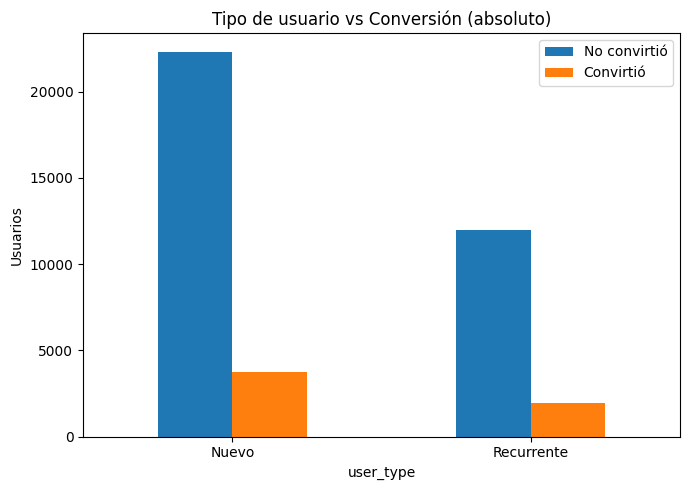

In [20]:
# Gráfico absoluto
tabla_usuario.plot(kind="bar", figsize=(7,5), title="Tipo de usuario vs Conversión (absoluto)")
plt.ylabel("Usuarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

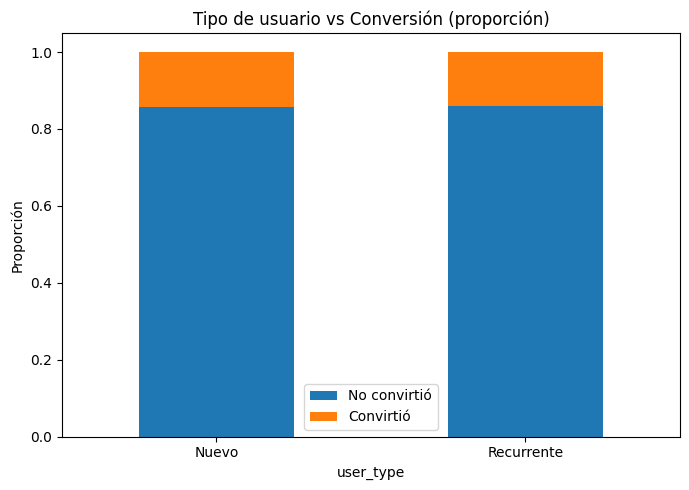

In [21]:
# Gráfico proporcional
tabla_usuario_pct = tabla_usuario.div(tabla_usuario.sum(axis=1), axis=0)
tabla_usuario_pct.plot(kind="bar", stacked=True, figsize=(7,5), title="Tipo de usuario vs Conversión (proporción)")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()